In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [14]:
df = pd.read_csv('../data/raw/sentiment-emotion-labelled_Dell_tweets.csv')
#Cancello prima colonna
df.drop(columns=df.columns[0], axis = 1, inplace=True)
print(f"Dimensioni: {df.shape[0]} righe, {df.shape[1]} colonne\n")
print(f"\nColonne presenti:")
print(df.columns.tolist())
print(f"\nTipi di dato:")
print(df.dtypes)
print(f"\nPrime 5 righe:")
df.head()

Dimensioni: 24970 righe, 8 colonne


Colonne presenti:
['Datetime', 'Tweet Id', 'Text', 'Username', 'sentiment', 'sentiment_score', 'emotion', 'emotion_score']

Tipi di dato:
Datetime            object
Tweet Id             int64
Text                object
Username            object
sentiment           object
sentiment_score    float64
emotion             object
emotion_score      float64
dtype: object

Prime 5 righe:


,Datetime,Tweet Id,Text,Username,sentiment,sentiment_score,emotion,emotion_score
0,2022-09-30 23:29:15+00:00,1575991191170342912,@Logitech @apple @Google @Microsoft @Dell @Len...,ManjuSreedaran,neutral,0.853283,anticipation,0.587121
1,2022-09-30 21:46:35+00:00,1575965354425131008,@MK_habit_addict @official_stier @MortalKombat...,MiKeMcDnet,neutral,0.519470,joy,0.886913
2,2022-09-30 21:18:02+00:00,1575958171423752203,"As @CRN celebrates its 40th anniversary, Bob F...",jfollett,positive,0.763791,joy,0.960347
3,2022-09-30 20:05:24+00:00,1575939891485032450,@dell your customer service is horrible especi...,daveccarr,negative,0.954023,anger,0.983203
4,2022-09-30 20:03:17+00:00,1575939359160750080,@zacokalo @Dell @DellCares @Dell give the man ...,heycamella,neutral,0.529170,anger,0.776124


In [15]:
#Valori null
print("\n VALORI MANCANTI:")
print(df.isnull().sum())

if df.isnull().sum().sum() == 0:
    print("✓ Nessun valore mancante!")

#Duplicati
print("\n DUPLICATI:")
print(f"  • Righe duplicate: {df.duplicated().sum()}")
print(f"  • Tweet duplicati (stesso testo): {df['Text'].duplicated().sum()}")
print(f"  • Tweet ID duplicati: {df['Tweet Id'].duplicated().sum()}")

# Mostra esempi di duplicati
if df['Text'].duplicated().sum() > 0:
    print("\n Esempi di tweet duplicati:")
    dup_mask = df['Text'].duplicated(keep=False)
    print(df[dup_mask][['Text', 'sentiment', 'emotion']].head(6))

#I duplicati vengono rimossi per evitare overfitting
print("RIMOZIONE DUPLICATI")

#Rimozione duplicati basata sul testo
df_clean = df.drop_duplicates(subset='Text', keep='first')

# Statistiche dopo la rimozione
print(f"Dataset dopo rimozione duplicati: {len(df_clean)} righe")
print(f"Righe rimosse: {len(df) - len(df_clean)}")
print(f"Percentuale dati mantenuti: {len(df_clean)/len(df)*100:.2f}%")

print(f"\nVerifica: Tweet duplicati rimasti: {df_clean['Text'].duplicated().sum()}")

df = df_clean


 VALORI MANCANTI:
Datetime           0
Tweet Id           0
Text               0
Username           0
sentiment          0
sentiment_score    0
emotion            0
emotion_score      0
dtype: int64
✓ Nessun valore mancante!

 DUPLICATI:
  • Righe duplicate: 0
  • Tweet duplicati (stesso testo): 331
  • Tweet ID duplicati: 0

 Esempi di tweet duplicati:
                                                  Text sentiment  emotion
32   @ashu_k7 @Dell Pathetic!!!!! I Dont mind takin...  negative    anger
36   @ashu_k7 @Dell Pathetic!!!!! I Dont mind takin...  negative    anger
68                             @Dell That’s very great  positive      joy
154                              @Dell This is amazing  positive      joy
269             @Dell Bad product Dell Inspiron laptop  negative  disgust
270             @Dell Bad product Dell Inspiron laptop  negative  disgust
RIMOZIONE DUPLICATI
Dataset dopo rimozione duplicati: 24639 righe
Righe rimosse: 331
Percentuale dati mantenuti: 98.67%

Veri

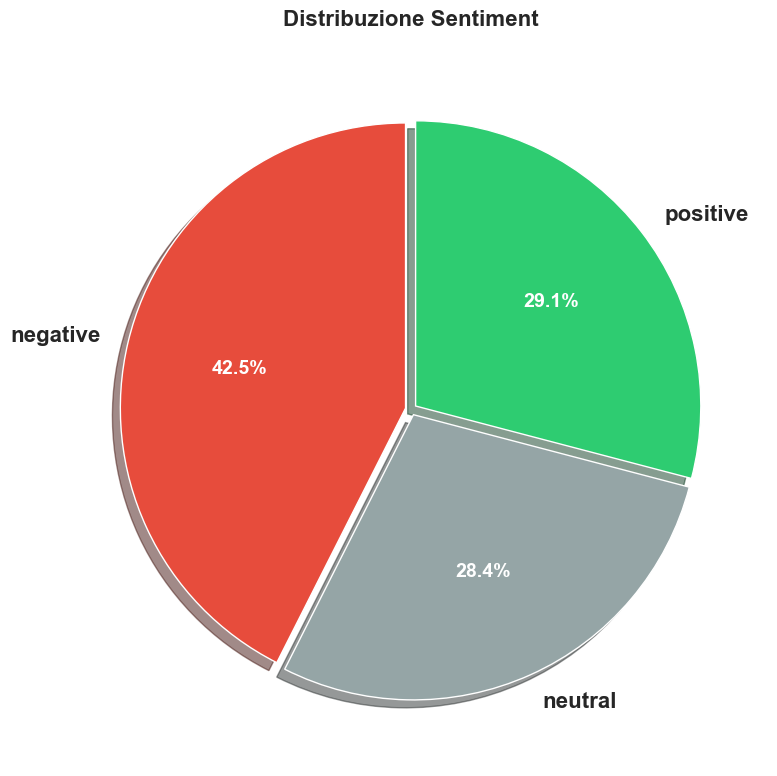

In [16]:
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

sentiment_order = ['negative', 'neutral', 'positive']
sentiment_counts = df['sentiment'].value_counts().reindex(sentiment_order)


colors = ['#e74c3c', '#95a5a6', '#2ecc71']

fig, ax = plt.subplots(figsize=(10, 8))

# Creazione il grafico con esplosione 
explode = (0.02, 0.02, 0.02)  

wedges, texts, autotexts = ax.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=explode,
    shadow=True,  
    textprops={'fontsize': 13, 'weight': 'bold'}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_weight('bold')

for text in texts:
    text.set_fontsize(16)
    text.set_weight('bold')

ax.set_title('Distribuzione Sentiment', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

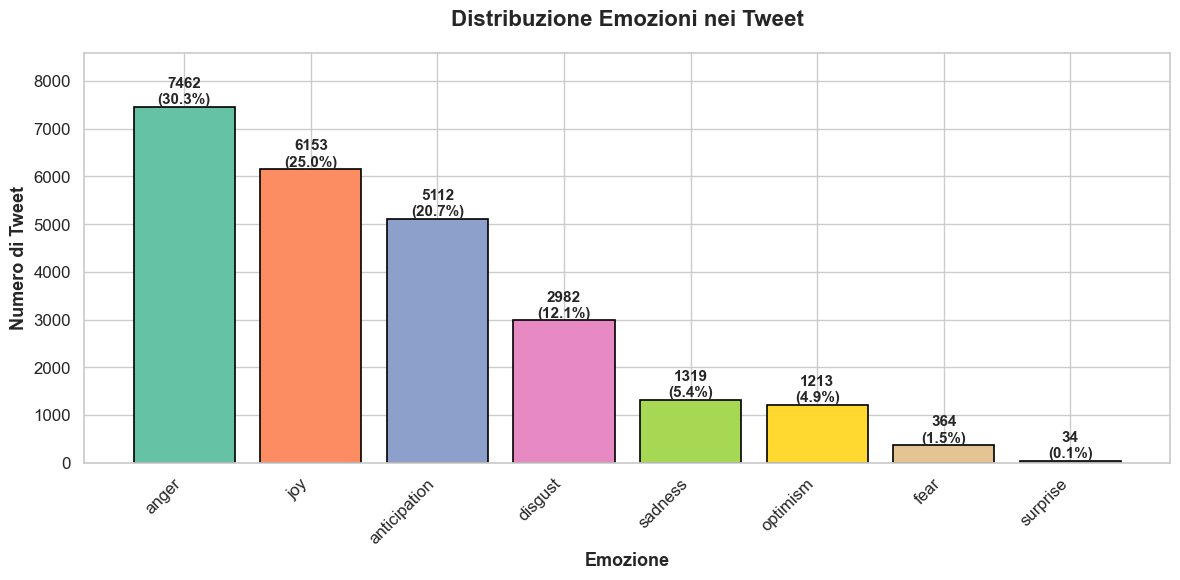

In [17]:
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

emotion_counts = df['emotion'].value_counts()

# Creazione grafico
fig, ax = plt.subplots(figsize=(12, 6))

colors = sns.color_palette("Set2", len(emotion_counts))

bars = ax.bar(emotion_counts.index, emotion_counts.values, color=colors, edgecolor='black', linewidth=1.2)

# Aggiungi i valori sopra le barre
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Distribuzione Emozioni nei Tweet', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Emozione', fontsize=13, fontweight='bold')
ax.set_ylabel('Numero di Tweet', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(emotion_counts.values) * 1.15) 
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

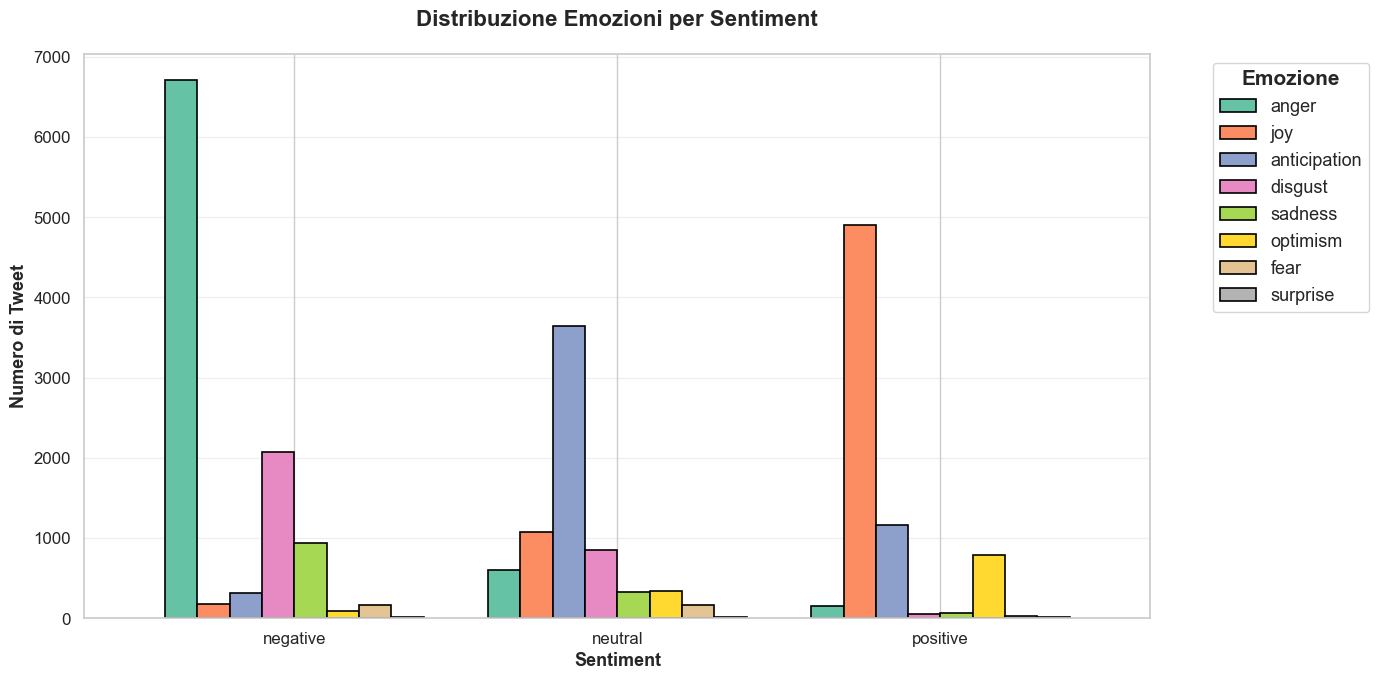

In [26]:
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

emotion_by_sentiment = pd.crosstab(df['sentiment'], df['emotion'])
emotion_by_sentiment = emotion_by_sentiment.reindex(['negative', 'neutral', 'positive'])

#Stesso ordine di prima per mantenere stessi colori
emotion_order = df['emotion'].value_counts().index.tolist()
emotion_by_sentiment = emotion_by_sentiment[emotion_order]

colors = sns.color_palette("Set2", len(emotion_by_sentiment.columns))

fig, ax = plt.subplots(figsize=(14, 7))

emotion_by_sentiment.plot(kind='bar', ax=ax, width=0.8, color=colors, edgecolor='black', linewidth=1.2)

ax.set_title('Distribuzione Emozioni per Sentiment', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Sentiment', fontsize=13, fontweight='bold')
ax.set_ylabel('Numero di Tweet', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
legend = ax.legend(title='Emozione', bbox_to_anchor=(1.05, 1), loc='upper left', 
                   fontsize=13, title_fontsize=15)
legend.get_title().set_fontweight('bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()